In [18]:
import torch
import torch.nn as nn
import time
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import os
from qiskit.circuit import QuantumCircuit, ParameterVector
from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import real_amplitudes
from qiskit.primitives import StatevectorEstimator
from qiskit_machine_learning.neural_networks import EstimatorQNN
from qiskit_machine_learning.connectors import TorchConnector
import math
from sklearn.metrics import roc_auc_score, f1_score, balanced_accuracy_score
from torchmetrics.classification import MulticlassCalibrationError
import json
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import EstimatorV2 as AerEstimator
from qiskit_algorithms.gradients import ParamShiftEstimatorGradient
from qiskit_aer.primitives import EstimatorV2 as AerEstimator
from qiskit_algorithms.gradients import SPSAEstimatorGradient



CURRENT_SEED = 17
COMPONENTS   = [32, 16, 8, 4]
N_QUBITS = 8

os.makedirs('../compressedFeatures', exist_ok=True)

In [19]:
#EfficientSU2
from qiskit.circuit.library import EfficientSU2

# Angular Scaling
Scala le feature compresse in (0, 2π] con min-max. Fit solo su train e transform su tutti e tre gli split.

In [20]:
def angular_scaling(X_train, X_val, X_test):

    scaler = MinMaxScaler(feature_range=(1e-6, 2 * np.pi)) #1e-6 perchè nn deve essere 0
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled   = scaler.transform(X_val)
    X_test_scaled  = scaler.transform(X_test)


    X_val_scaled  = np.clip(X_val_scaled,  1e-6, 2 * np.pi)
    X_test_scaled = np.clip(X_test_scaled, 1e-6, 2 * np.pi)

    return X_train_scaled, X_val_scaled, X_test_scaled, scaler

In [21]:
for d in COMPONENTS:

    path = f'../compressedFeatures/pca_d{d}_seed_{CURRENT_SEED}.pt'
    ckpt = torch.load(path, weights_only=False)

    X_train = ckpt['train'].numpy()
    X_val   = ckpt['val'].numpy()
    X_test  = ckpt['test'].numpy()


    X_train_ang, X_val_ang, X_test_ang, scaler = angular_scaling(
        X_train, X_val, X_test
    )

    print(f'd={d:2d} \nrange train: [{X_train_ang.min():.4f}, {X_train_ang.max():.4f}]')
    print(f'range val:   [{X_val_ang.min():.4f}, {X_val_ang.max():.4f}]')
    print(f'range test:  [{X_test_ang.min():.4f}, {X_test_ang.max():.4f}]\n')


    torch.save({
        'train_ang':       torch.from_numpy(X_train_ang).float(),
        'val_ang':         torch.from_numpy(X_val_ang).float(),
        'test_ang':        torch.from_numpy(X_test_ang).float(),
        'y_train':         ckpt['y_train'],
        'y_val':           ckpt['y_val'],
        'y_test':          ckpt['y_test'],
        'd':               d,
        'seed':            CURRENT_SEED,
        'angular_scaling': 'minmax_(0,2pi]'
    }, f'../compressedFeatures/angular_d{d}_seed_{CURRENT_SEED}.pt')

d=32 
range train: [0.0000, 6.2832]
range val:   [0.0000, 6.2832]
range test:  [0.0000, 6.2832]

d=16 
range train: [0.0000, 6.2832]
range val:   [0.0000, 6.2832]
range test:  [0.0000, 6.2832]

d= 8 
range train: [0.0000, 6.2832]
range val:   [0.0000, 6.2832]
range test:  [0.0000, 6.2832]

d= 4 
range train: [0.0000, 6.2832]
range val:   [0.0000, 6.2832]
range test:  [0.0000, 4.4962]



# Angle Encoding con Data Re-Uploading

In [22]:
def build_encoding_layer(d, n_qubits, block_idx):

    # Costruisce un layer di encoding RY per un singolo blocco. Restituisce il circuito e i parametri di encoding del blocco.

    params = ParameterVector(f'x_{block_idx}', n_qubits) # ParameterVector è una lista di variabili simboliche non ha ancora valori numerici, sono solo nomi che venmgono sostituiti quando si esegue il circuito
    qc = QuantumCircuit(n_qubits)
    for i in range(n_qubits):
        qc.ry(params[i], i)
    return qc, params

def build_encoding_circuit(d, n_qubits=N_QUBITS):

    # Costruisce il circuito di encoding completo con data re-uploading. Per ogni blocco di nqubits feature applica RY su tutti i qubit.
    # Se d non è divisibile per n_qubits, l'ultimo blocco viene zero-paddato.

    n_blocks = math.ceil(d / n_qubits)
    
    qc = QuantumCircuit(n_qubits)
    all_input_params = []

    for block in range(n_blocks):
        enc_layer, enc_params = build_encoding_layer(d, n_qubits, block)
        qc.compose(enc_layer, inplace=True)
        all_input_params.extend(enc_params)

    return qc, all_input_params, n_blocks

# verifica per ogni d
for d in COMPONENTS:
    qc, input_params, n_blocks = build_encoding_circuit(d, N_QUBITS)
    print(f'd={d:2d} | blocchi={n_blocks} | parametri encoding={len(input_params)} | padding={n_blocks*N_QUBITS - d}')


d=32 | blocchi=4 | parametri encoding=32 | padding=0
d=16 | blocchi=2 | parametri encoding=16 | padding=0
d= 8 | blocchi=1 | parametri encoding=8 | padding=0
d= 4 | blocchi=1 | parametri encoding=8 | padding=4


In [23]:
qc_example, _, _ = build_encoding_circuit(d=32, n_qubits=N_QUBITS)
qc_example.draw('text')
#qc_example.draw('mpl')
#qc_example.draw('latex')

┌────────────┐┌────────────┐┌────────────┐┌────────────┐
q_0: ┤ Ry(x_0[0]) ├┤ Ry(x_1[0]) ├┤ Ry(x_2[0]) ├┤ Ry(x_3[0]) ├
     ├────────────┤├────────────┤├────────────┤├────────────┤
q_1: ┤ Ry(x_0[1]) ├┤ Ry(x_1[1]) ├┤ Ry(x_2[1]) ├┤ Ry(x_3[1]) ├
     ├────────────┤├────────────┤├────────────┤├────────────┤
q_2: ┤ Ry(x_0[2]) ├┤ Ry(x_1[2]) ├┤ Ry(x_2[2]) ├┤ Ry(x_3[2]) ├
     ├────────────┤├────────────┤├────────────┤├────────────┤
q_3: ┤ Ry(x_0[3]) ├┤ Ry(x_1[3]) ├┤ Ry(x_2[3]) ├┤ Ry(x_3[3]) ├
     ├────────────┤├────────────┤├────────────┤├────────────┤
q_4: ┤ Ry(x_0[4]) ├┤ Ry(x_1[4]) ├┤ Ry(x_2[4]) ├┤ Ry(x_3[4]) ├
     ├────────────┤├────────────┤├────────────┤├────────────┤
q_5: ┤ Ry(x_0[5]) ├┤ Ry(x_1[5]) ├┤ Ry(x_2[5]) ├┤ Ry(x_3[5]) ├
     ├────────────┤├────────────┤├────────────┤├────────────┤
q_6: ┤ Ry(x_0[6]) ├┤ Ry(x_1[6]) ├┤ Ry(x_2[6]) ├┤ Ry(x_3[6]) ├
     ├────────────┤├────────────┤├────────────┤├────────────┤
q_7: ┤ Ry(x_0[7]) ├┤ Ry(x_1[7]) ├┤ Ry(x_2[7]) ├┤ Ry(x_3[7]) ├
     └────────────┘└────────────┘└────────────┘└────────────┘

# Ansatz RealAmplitudes Shallow

Ansatz 2-local che agisce su coppie di qubit adiacenti. È composto da due tipi di gate alternati:
- gate RY su ogni qubit con un parametro variazionale (layer di rotazione)
- gate CNOT tra qubit adiacenti che creano correlazioni quantistiche (layer di entanglement)

Visto che è shallow -> reps = 1

In [24]:
def build_ansatz_layer(n_qubits, reps, entanglement, block_idx, ansatzType='RealAmplitudes'):
    if ansatzType == 'RealAmplitudes':
        ansatz = real_amplitudes(
            num_qubits=n_qubits,
            reps=reps,
            entanglement=entanglement,
            parameter_prefix=f'θ_{block_idx}'
        )
    elif ansatzType == 'EfficientSU2':
        ansatz = EfficientSU2(
            num_qubits=n_qubits,
            reps=reps,
            entanglement=entanglement,
            parameter_prefix=f'θ_{block_idx}'
        )
    else:
        raise ValueError(f"Ansatz type '{ansatz_type}' non supportato.")
    return ansatz

In [25]:
def build_vqc_circuit(d, n_qubits=N_QUBITS, reps=1, entanglement='linear', ansatzType='RealAmplitudes'):
    n_blocks = math.ceil(d / n_qubits)
    qc = QuantumCircuit(n_qubits)
    all_input_params       = []
    all_variational_params = []

    for block in range(n_blocks):
        # encoding
        enc_layer, enc_params = build_encoding_layer(d, n_qubits, block)
        qc.compose(enc_layer, inplace=True)
        all_input_params.extend(enc_params)
        # ansatz dopo ogni blocco
        ansatz = build_ansatz_layer(n_qubits, reps, entanglement, block, ansatzType=ansatzType)
        qc.compose(ansatz, inplace=True)
        all_variational_params.extend(ansatz.parameters)

    return qc.decompose(), all_input_params, all_variational_params, n_blocks

In [26]:
for d in COMPONENTS:
    qc, input_params, var_params, n_blocks = build_vqc_circuit(d, N_QUBITS)
    n_cnot = qc.count_ops().get('cx', 0)
    print(f'd={d:2d} | blocchi={n_blocks} | param_encoding={len(input_params):3d} | param_variazionali={len(var_params):3d} | CNOT totali={n_cnot}')

d=32 | blocchi=4 | param_encoding= 32 | param_variazionali= 64 | CNOT totali=28
d=16 | blocchi=2 | param_encoding= 16 | param_variazionali= 32 | CNOT totali=14
d= 8 | blocchi=1 | param_encoding=  8 | param_variazionali= 16 | CNOT totali=7
d= 4 | blocchi=1 | param_encoding=  8 | param_variazionali= 16 | CNOT totali=7


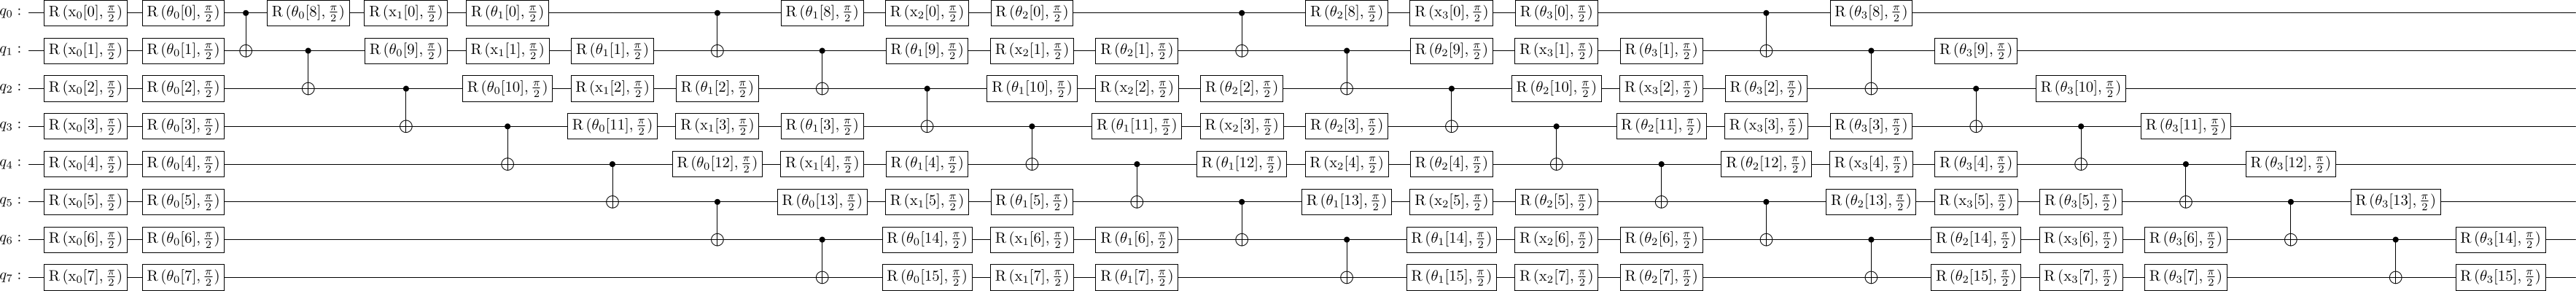

In [27]:
qc_example, _, _, _ = build_vqc_circuit(d=32, n_qubits=N_QUBITS)
qc_example.draw('latex')

In [28]:
def build_qnn(d, n_qubits=N_QUBITS, ansatzType='RealAmplitudes', reps=1, readout_selector="z", spsa_epsilon=1e-3, spsa_batch_size=1):
    
    qc, input_params, var_params, n_blocks = build_vqc_circuit(d, n_qubits, reps=reps, ansatzType=ansatzType)
    observables = build_observables(n_qubits, readout_selector)

    # Estimator V2 con backend aer-statevector ed estimator_precision = "exact"
    estimator = AerEstimator(
        options={
            "backend_options": {"method": "statevector"},
            "run_options": {"shots": None}
        }
    )

    # Gradient selector = "spsa" applicato solo ai pesi quantistici
    gradient = SPSAEstimatorGradient(
        estimator=estimator,
        epsilon=spsa_epsilon,
        batch_size=spsa_batch_size
    )

    qnn = EstimatorQNN(
        circuit=qc,
        observables=observables,
        input_params=input_params,
        weight_params=var_params,
        estimator=estimator,
        gradient=gradient  
    )

    print(f'd={d:2d} | ansatz={ansatzType} | reps={reps} | readout={readout_selector} ({len(observables)} valori)')
    return qnn

# verifica per ogni d
for d in COMPONENTS:
    qnn = build_qnn(d, N_QUBITS)

d=32 | ansatz=RealAmplitudes | reps=1 | readout=z (8 valori)
d=16 | ansatz=RealAmplitudes | reps=1 | readout=z (8 valori)
d= 8 | ansatz=RealAmplitudes | reps=1 | readout=z (8 valori)
d= 4 | ansatz=RealAmplitudes | reps=1 | readout=z (8 valori)


In [29]:
import qiskit_aer
import qiskit_machine_learning
print(f'qiskit-aer: {qiskit_aer.__version__}')
print(f'qiskit-machine-learning: {qiskit_machine_learning.__version__}')

qiskit-aer: 0.17.2
qiskit-machine-learning: 0.9.0


In [30]:

def build_hybrid_model(d, n_qubits=N_QUBITS, ansatzType='RealAmplitudes', reps=1, readout_selector="z", spsa_epsilon=1e-3, spsa_batch_size=1):
    qnn = build_qnn(d, n_qubits, ansatzType, reps, readout_selector, spsa_epsilon, spsa_batch_size)
    n_observables = len(build_observables(n_qubits, readout_selector))
    
    model = nn.Sequential(
        TorchConnector(qnn),
        nn.Linear(n_observables, 4) # La testa lineare ora si adatta alla dimensione del readout
    )
    return model

# test con d=4
model = build_hybrid_model(d=4, n_qubits=N_QUBITS, ansatzType='EfficientSU2')
print(model)

d= 4 | ansatz=EfficientSU2 | reps=1 | readout=z (8 valori)
Sequential(
  (0): TorchConnector()
  (1): Linear(in_features=8, out_features=4, bias=True)
)


C:\Users\shali\AppData\Local\Temp\ipykernel_11996\657980246.py:10: DeprecationWarning: The class ``qiskit.circuit.library.n_local.efficient_su2.EfficientSU2`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.efficient_su2 instead.
  ansatz = EfficientSU2(


In [31]:
def init_weights(model, seed):
    # Inizializzazione parametri circuitali ~ U(-0.01, 0.01) come da handout.

    torch.manual_seed(seed)
    for name, param in model.named_parameters():
        if 'weight' in name and param.shape == torch.Size([4, N_QUBITS]):
            nn.init.xavier_uniform_(param)
        else:
            nn.init.uniform_(param, -0.1, 0.1)  # da -0.01 e 0.01
    return model

In [32]:
def apply_padding(X, d, n_qubits):

    import math
    n_blocks = math.ceil(d / n_qubits)
    padded_size = n_blocks * n_qubits
    if padded_size == d:
        return X  # nessun padding necessario
    pad = torch.zeros(X.shape[0], padded_size - d)
    return torch.cat([X, pad], dim=1)

def train_vqc(d, n_qubits=N_QUBITS, n_epochs=50, batch_size=4, patience=7, seed=CURRENT_SEED, 
              ansatzType='RealAmplitudes', reps=1, readout_selector="z", 
              spsa_epsilon=1e-3, spsa_batch_size=1, lr=0.01):
    
    # 1. CARICAMENTO DEI DATI ANGOLARI GENERATI IN PRECEDENZA
    path = f'../compressedFeatures/angular_d{d}_seed_{seed}.pt'
    if not os.path.exists(path):
        raise FileNotFoundError(f"File non trovato: {path}. Assicurati di aver generato i dataset compressi.")
        
    ckpt = torch.load(path, weights_only=False)
    
    # 2. APPLICAZIONE DEL PADDING SULLE FEATURE
    X_train = apply_padding(ckpt['train_ang'], d, n_qubits)
    X_val   = apply_padding(ckpt['val_ang'], d, n_qubits)
    
    y_train = ckpt['y_train'].squeeze().long()
    y_val   = ckpt['y_val'].squeeze().long()
    
    # 3. CREAZIONE DATALOADER 
    train_ds = TensorDataset(X_train, y_train)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    
    val_ds = TensorDataset(X_val, y_val)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    # 4. COSTRUZIONE MODELLO
    model = build_hybrid_model(d, n_qubits, ansatzType, reps, readout_selector, spsa_epsilon, spsa_batch_size)
    model = init_weights(model, seed)

    loss_fn = nn.CrossEntropyLoss()
    

    optimizer = optim.Adam(model.parameters(), lr=lr)

    best_val_loss = float('inf')
    patience_counter = 0
    best_weights = None
    history = {'train_loss': [], 'val_loss': []}

    # 5. LOOP DI ADDESTRAMENTO
    for epoch in range(n_epochs):
        model.train()
        epoch_losses = []
        
        for batch_idx, (X_batch, y_batch) in enumerate(train_loader):

            start = time.perf_counter()
            
            optimizer.zero_grad()
            logits = model(X_batch) 
            loss = loss_fn(logits, y_batch) 
            loss.backward()  
            optimizer.step()
            
            elapsed = time.perf_counter() - start 
            epoch_losses.append(loss.item())
            if batch_idx % 5 == 0: 
                print(f"    ...elaborando batch {batch_idx}...", end="\r")
            # Monitoraggio yempo primo batch del ciclo
            if batch_idx == 0:
                print(f"Epoch {epoch+1:02d}/{n_epochs:02d} | Batch_0 Time: {elapsed:.4f}s")
                if elapsed > 15.0:
                    print("Il batch è troppo lento. Riduci la dimensione o le reps.")

        train_loss = np.mean(epoch_losses)
        history['train_loss'].append(train_loss)
        
        # 6. LOOP DI VALIDAZIONE REALE
        model.eval()
        val_losses = []
        with torch.no_grad():
            for X_val_b, y_val_b in val_loader:
                val_logits = model(X_val_b)
                val_loss_b = loss_fn(val_logits, y_val_b)
                val_losses.append(val_loss_b.item())
                
        val_loss = np.mean(val_losses)
        history['val_loss'].append(val_loss)
        
        print(f"  -> Loss di Addestramento: {train_loss:.4f} | Loss di Validazione: {val_loss:.4f}")
        

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            # Copia profonda dello stato dei parametri migliori
            best_weights = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping attivato all'epoca {epoch+1}. Ripristino dei parametri ottimali.")
                break
                

    if best_weights is not None:
        model.load_state_dict(best_weights)
        
    return model, history

In [33]:

os.makedirs('../artifacts', exist_ok=True)

def evaluate_vqc(model, X, y, n_classes=4):
    
    model.eval()
    with torch.no_grad():
        logits = model(X)
        probs  = torch.softmax(logits, dim=1).numpy()
        preds  = probs.argmax(axis=1)
    y_np = y.numpy()

    auroc = roc_auc_score(y_np, probs, multi_class='ovr', average='macro')
    f1    = f1_score(y_np, preds, average='macro', zero_division=0)
    bacc  = balanced_accuracy_score(y_np, preds)

    ece_metric = MulticlassCalibrationError(num_classes=n_classes, n_bins=15, norm='l1')
    ece = ece_metric(
        torch.tensor(probs, dtype=torch.float32),
        torch.tensor(y_np,  dtype=torch.long)
    ).item()

    return {
        'macro_auroc': round(auroc, 4),
        'macro_f1':    round(f1,   4),
        'bal_acc':     round(bacc, 4),
        'ece':         round(ece,  4)
    }, preds, probs


def save_vqc_artifact(d, seed, ansatz_name, val_metrics, test_metrics, y_val, val_preds, val_probs, y_test, test_preds, test_probs, history):

    artifact = {
        'd':            d,
        'seed':         seed,
        'model':        'VQC',
        'ansatz':       ansatz_name,
        'n_qubits':     N_QUBITS,
        'compression':  'pca_baseline',
        'type':         'quantum_baseline',
        'val_metrics':  val_metrics,
        'test_metrics': test_metrics
    }
    json_path = f'../artifacts/vqc_{ansatz_name}_d{d}_seed_{seed}.json'
    with open(json_path, 'w') as f:
        json.dump(artifact, f, indent=2)

    np.savez(
        f'../artifacts/vqc_{ansatz_name}_d{d}_seed_{seed}_preds.npz',
        val_y_true=y_val,    val_y_pred=val_preds,   val_probs=val_probs,
        test_y_true=y_test,  test_y_pred=test_preds, test_probs=test_probs,
        train_loss=np.array(history['train_loss']),
        val_loss=np.array(history['val_loss'])
    )
    print(f'Salvato: {json_path}')

In [34]:
def evaluate_and_save(model, d, history, seed=CURRENT_SEED, ansatz_name='RealAmplitudes_C1'):
    ckpt = torch.load(
        f'../compressedFeatures/angular_d{d}_seed_{seed}.pt',
        weights_only=False
    )
    X_val  = apply_padding(ckpt['val_ang'],  d, N_QUBITS)
    X_test = apply_padding(ckpt['test_ang'], d, N_QUBITS)
    y_val  = ckpt['y_val'].squeeze().long()
    y_test = ckpt['y_test'].squeeze().long()

    val_metrics,  val_preds,  val_probs  = evaluate_vqc(model, X_val,  y_val)
    test_metrics, test_preds, test_probs = evaluate_vqc(model, X_test, y_test)

    print(f'd={d:2d}')
    print(f'  VAL  → AUROC={val_metrics["macro_auroc"]:.4f} | F1={val_metrics["macro_f1"]:.4f} | BalAcc={val_metrics["bal_acc"]:.4f} | ECE={val_metrics["ece"]:.4f}')
    print(f'  TEST → AUROC={test_metrics["macro_auroc"]:.4f} | F1={test_metrics["macro_f1"]:.4f} | BalAcc={test_metrics["bal_acc"]:.4f} | ECE={test_metrics["ece"]:.4f}')

    save_vqc_artifact(
        d=d, seed=seed,
        ansatz_name=ansatz_name,
        val_metrics=val_metrics,  test_metrics=test_metrics,
        y_val=y_val.numpy(),      val_preds=val_preds,    val_probs=val_probs,
        y_test=y_test.numpy(),    test_preds=test_preds,  test_probs=test_probs,
        history=history
    )

In [35]:
def build_observables(n_qubits, readout_selector="z"):
    observables = []
    
    # 1. Readout Z: (8 valori)
    if readout_selector in ["z", "x_y_z", "x_y_z_pair_nn"]:
        for i in range(n_qubits):
            pauli_str = 'I' * (n_qubits - i - 1) + 'Z' + 'I' * i
            observables.append(SparsePauliOp(pauli_str))
            
    # 2. Readout X_Y_Z (24 valori)
    if readout_selector in ["x_y_z", "x_y_z_pair_nn"]:
        for i in range(n_qubits):
            pauli_str_x = 'I' * (n_qubits - i - 1) + 'X' + 'I' * i
            pauli_str_y = 'I' * (n_qubits - i - 1) + 'Y' + 'I' * i
            observables.extend([SparsePauliOp(pauli_str_x), SparsePauliOp(pauli_str_y)])
            
    # 3. Readout X_Y_Z_PAIR_NN (45 valori)
    if readout_selector == "x_y_z_pair_nn":
        for i in range(n_qubits - 1):
            for pauli in ['XX', 'YY', 'ZZ']:
                pauli_str = 'I' * (n_qubits - i - 2) + pauli + 'I' * i
                observables.append(SparsePauliOp(pauli_str))
                
    return observables

In [38]:

model_d8, history_d8 = train_vqc(
    d=8, 
    n_qubits=N_QUBITS, 
    n_epochs=10,       
    batch_size=2, 
    reps=1,            
    patience=5, 
    seed=CURRENT_SEED,
    ansatzType='RealAmplitudes',
    readout_selector='z', 
    spsa_epsilon=1e-3, 
    spsa_batch_size=1  
)


val_min = min(history_d8['val_loss'])
print(f"Test d=8 completato. Min Val Loss: {val_min:.4f}")

d= 8 | ansatz=RealAmplitudes | reps=1 | readout=z (8 valori)
Epoch 01/10 | Batch_0 Time: 0.0748s
  -> Loss di Addestramento: 1.3175 | Loss di Validazione: 1.3146
Epoch 02/10 | Batch_0 Time: 0.0620s


KeyboardInterrupt: 

In [36]:
# --- ADDESTRAMENTO INIZIALE DI VERIFICA (d=32 con parametri ottimizzati) ---
model_d32, history_d32 = train_vqc(
    d=32, 
    ansatzType='EfficientSU2', #RealAmplitudes
    n_qubits=N_QUBITS, 
    n_epochs=50, 
    batch_size=4,          
    patience=10, 
    seed=CURRENT_SEED, 
    readout_selector="z", #x_y_z_pair_all, x_y_z_pair_nn, x_y_z, z
    reps=1,              
    spsa_batch_size=1,     
    lr=0.01
)


evaluate_and_save(model_d32, d=32, history=history_d32, ansatz_name='EfficientSU2_C1')


# --- RICERCA IPERPARAMETRI SU d=4---
print('\nRicerca iperparametri (Learning Rate di Adam) su d=4 (30 epoche)')
print('=' * 60)

# comportamento di Adam su d=4
for lr_test in [0.001, 0.01, 0.05]:
    print(f"Esecuzione test con Adam Learning Rate = {lr_test}")
    model_test, history_test = train_vqc(
        d=4, 
        n_qubits=N_QUBITS,
        n_epochs=15, 
        batch_size=4,      
        patience=5, 
        seed=CURRENT_SEED,
        ansatzType='EfficientSU2', #RealAmplitudes
        readout_selector='z',
        spsa_epsilon=1e-3, 
        lr=lr_test
    )
    val_min = min(history_test['val_loss'])
    print(f"Risultato lr={lr_test} | Min Val Loss registrata: {val_min:.4f}")
    print('-' * 60)

C:\Users\shali\AppData\Local\Temp\ipykernel_11996\657980246.py:10: DeprecationWarning: The class ``qiskit.circuit.library.n_local.efficient_su2.EfficientSU2`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.efficient_su2 instead.
  ansatz = EfficientSU2(


d=32 | ansatz=EfficientSU2 | reps=1 | readout=z (8 valori)
Epoch 01/50 | Batch_0 Time: 1.2838s
  -> Loss di Addestramento: 1.3442 | Loss di Validazione: 1.3362
Epoch 02/50 | Batch_0 Time: 0.9623s
  -> Loss di Addestramento: 1.2939 | Loss di Validazione: 1.2741
Epoch 03/50 | Batch_0 Time: 1.0481s
  -> Loss di Addestramento: 1.2834 | Loss di Validazione: 1.2887
Epoch 04/50 | Batch_0 Time: 1.0244s
  -> Loss di Addestramento: 1.3097 | Loss di Validazione: 1.3498
Epoch 05/50 | Batch_0 Time: 1.0540s
  -> Loss di Addestramento: 1.3099 | Loss di Validazione: 1.2907
Epoch 06/50 | Batch_0 Time: 0.8989s
  -> Loss di Addestramento: 1.2983 | Loss di Validazione: 1.2784
Epoch 07/50 | Batch_0 Time: 0.9070s
  -> Loss di Addestramento: 1.2783 | Loss di Validazione: 1.2675
Epoch 08/50 | Batch_0 Time: 0.9164s
  -> Loss di Addestramento: 1.3221 | Loss di Validazione: 1.3089
Epoch 09/50 | Batch_0 Time: 0.9532s
  -> Loss di Addestramento: 1.3073 | Loss di Validazione: 1.2791
Epoch 10/50 | Batch_0 Time: 0.98

KeyboardInterrupt: 